# Network Intrusion Detection Project

For this project, I used the CIC-IDS2017 dataset to train a model that can tell the difference between normal network traffic and attacks. I put the data into two groups: benign and malicious.

## What I did

First, I combined the eight data files and cleaned up the missing values and duplicate rows. I looked at the different traffic labels, trained three models, and compared their results. At the end, I checked which features were important and saved the model with the best score.

## 1. Setup

In [1]:
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 100)

PROJECT_ROOT = Path.cwd().parent
DATA_DIR = PROJECT_ROOT / "data" / "raw"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

RANDOM_STATE = 42

## 2. Loading the data

The dataset came in eight CSV files containing network traffic from different days. I loaded each file, removed the extra spaces from the column names, and combined everything into one dataset.

In [2]:
t0 = time.time()
frames = []
for f in sorted(DATA_DIR.glob("*.csv")):
    d = pd.read_csv(f, encoding="utf-8", low_memory=False)
    d.columns = d.columns.str.strip()
    frames.append(d)
    print(f"{f.name:55s} {d.shape}")

df = pd.concat(frames, ignore_index=True)
del frames
print(f"\nCombined shape: {df.shape}  ({time.time() - t0:.1f}s)")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv        (225745, 79)
Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv    (286467, 79)
Friday-WorkingHours-Morning.pcap_ISCX.csv               (191033, 79)
Monday-WorkingHours.pcap_ISCX.csv                       (529918, 79)
Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv (288602, 79)
Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv  (170366, 79)
Tuesday-WorkingHours.pcap_ISCX.csv                      (445909, 79)
Wednesday-workingHours.pcap_ISCX.csv                    (692703, 79)

Combined shape: (2830743, 79)  (19.5s)
Memory usage: 1923 MB


## 3. Cleaning the data

Before training the models, I fixed a few problems in the data:

- Some labels had a strange character in them, so I replaced it with a normal hyphen.
- A few rows had infinite values because the flow duration was zero. I changed these to missing values and removed those rows.
- I removed duplicate rows so the same network flow would not be used more than once.
- Since the dataset is large, I changed the numeric columns to float32 to use less memory.

In [3]:
df["Label"] = df["Label"].str.replace("�", "-", regex=False).str.strip()

num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].astype("float32")

df[num_cols] = df[num_cols].replace([np.inf, -np.inf], np.nan)
n_before = len(df)
df = df.dropna(subset=num_cols)
print(f"Dropped {n_before - len(df):,} rows with inf/NaN values ({(n_before - len(df)) / n_before:.3%})")

n_before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Dropped {n_before - len(df):,} duplicate rows ({(n_before - len(df)) / n_before:.1%})")

print(f"\nFinal cleaned shape: {df.shape}")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.0f} MB")

Dropped 2,867 rows with inf/NaN values (0.101%)
Dropped 329,896 duplicate rows (11.7%)

Final cleaned shape: (2497980, 79)
Memory usage: 917 MB


## 4. Checking the class balance

Before putting all the attacks into one group, I checked how many rows there were for each original label. This helped me see which attacks were common and which ones only had a few examples.

Label
BENIGN                        2072254
DoS Hulk                       172846
DDoS                           128014
PortScan                        90694
DoS GoldenEye                   10282
FTP-Patator                      5931
DoS slowloris                    5374
DoS Slowhttptest                 5228
SSH-Patator                      3219
Bot                              1948
Web Attack - Brute Force         1470
Web Attack - XSS                  652
Infiltration                       36
Web Attack - Sql Injection         21
Heartbleed                         11
Name: count, dtype: int64


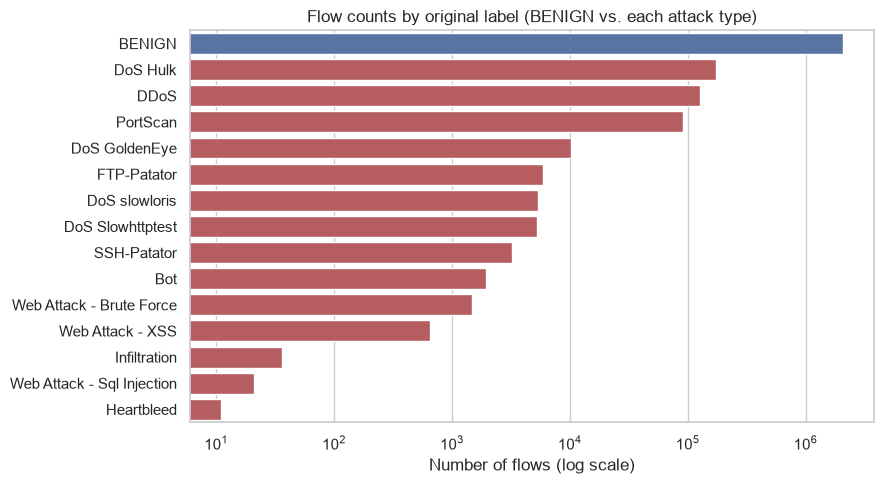

In [4]:
label_counts = df["Label"].value_counts()
print(label_counts)

fig, ax = plt.subplots(figsize=(9, 5))
order = label_counts.index
colors = ["#4C72B0" if l == "BENIGN" else "#C44E52" for l in order]
sns.barplot(x=label_counts.values, y=order, hue=order, palette=colors, legend=False, ax=ax)
ax.set_xscale("log")
ax.set_xlabel("Number of flows (log scale)")
ax.set_ylabel("")
ax.set_title("Flow counts by original label (BENIGN vs. each attack type)")
plt.tight_layout()
plt.show()

### 5. Creating the target labels

I changed the labels into numbers so the models could use them. Benign traffic is 0 and any type of attack is 1. About 80% of the data is benign, so I used class weights and checked precision and recall along with accuracy.

Label
Benign       0.829572
Malicious    0.170428
Name: proportion, dtype: float64


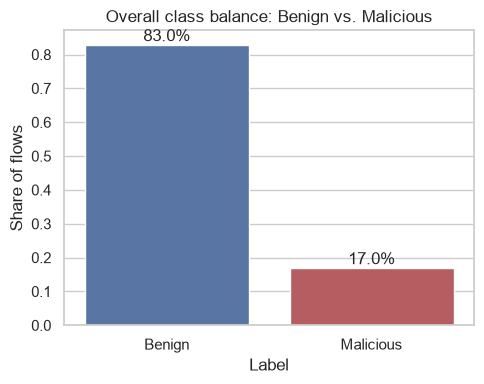


Feature matrix shape: (2497980, 78)


In [5]:
CLASS_NAMES = ["Benign", "Malicious"]

y = (df["Label"] != "BENIGN").astype(int)
X = df.drop(columns=["Label"])

balance = y.value_counts(normalize=True).rename(index={0: "Benign", 1: "Malicious"})
print(balance)

fig, ax = plt.subplots(figsize=(5, 4))
sns.barplot(x=balance.index, y=balance.values, hue=balance.index,
            palette=["#4C72B0", "#C44E52"], legend=False, ax=ax)
ax.set_ylabel("Share of flows")
ax.set_title("Overall class balance: Benign vs. Malicious")
for i, v in enumerate(balance.values):
    ax.text(i, v + 0.01, f"{v:.1%}", ha="center")
plt.tight_layout()
plt.show()

print(f"\nFeature matrix shape: {X.shape}")

## 6. Splitting the data

I used 80% of the data for training and kept 20% for testing. I used a stratified split so both sets had about the same amount of benign and malicious traffic. I scaled the training data for logistic regression, but random forest and XGBoost used the original values because tree models do not need scaling.

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance:\n{y_train.value_counts(normalize=True)}")

Train: (1998384, 78), Test: (499596, 78)
Train class balance:
Label
0    0.829572
1    0.170428
Name: proportion, dtype: float64


## 7. Training the models

I trained three different models to see which one worked best:

| Model | Why I used it |
|---|---|
| Logistic Regression | A simple model to use as a starting point |
| Random Forest | Can find more complicated patterns and show feature importance |
| XGBoost | Often works well with data in tables like this |

I used class weights because there were fewer attack examples than benign examples.

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

trained = {}  


def train_and_predict(name, model, uses_scaled):
    Xtr = X_train_scaled if uses_scaled else X_train
    Xte = X_test_scaled if uses_scaled else X_test

    t0 = time.time()
    model.fit(Xtr, y_train)
    train_time = time.time() - t0

    y_pred = model.predict(Xte)
    y_proba = model.predict_proba(Xte)[:, 1]

    trained[name] = dict(
        model=model, uses_scaled=uses_scaled,
        y_pred=y_pred, y_proba=y_proba, train_time=train_time,
    )
    print(f"{name}: trained in {train_time:.1f}s")

In [8]:
log_reg = LogisticRegression(max_iter=1000, class_weight="balanced")
train_and_predict("Logistic Regression", log_reg, uses_scaled=True)

Logistic Regression: trained in 74.5s


In [9]:
rand_forest = RandomForestClassifier(
    n_estimators=200, class_weight="balanced_subsample",
    n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("Random Forest", rand_forest, uses_scaled=False)

Random Forest: trained in 414.5s


In [10]:
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()  # balances XGBoost the way class_weight does for sklearn

xgb_clf = xgb.XGBClassifier(
    n_estimators=300, max_depth=6, learning_rate=0.1,
    scale_pos_weight=scale_pos_weight, eval_metric="logloss",
    tree_method="hist", n_jobs=-1, random_state=RANDOM_STATE,
)
train_and_predict("XGBoost", xgb_clf, uses_scaled=False)

XGBoost: trained in 87.4s


## 8. Comparing the Models

Iused a few different scores to compare the models:

- **Accuracy:** how many predictions were correct overall
- **Precision:** how often traffic predicted as an attack was actually an attack
- **Recall:** how many of the real attacks the model found
- **F1 score:** a score that combines precision and recall
- **ROC-AUC:** how well the model separates benign traffic from attacks

I focused mostly on the F1 score because the two classes were not evenly balanced.

In [11]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    roc_curve, precision_recall_curve,
)

metrics_rows = []
for name, info in trained.items():
    y_pred, y_proba = info["y_pred"], info["y_proba"]
    metrics_rows.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba),
        "Train time (s)": info["train_time"],
    })
    print(f"=== {name} ===")
    print(classification_report(y_test, y_pred, target_names=CLASS_NAMES, digits=4))

=== Logistic Regression ===
              precision    recall  f1-score   support

      Benign     0.9948    0.9325    0.9627    414451
   Malicious     0.7483    0.9762    0.8472     85145

    accuracy                         0.9400    499596
   macro avg     0.8715    0.9544    0.9049    499596
weighted avg     0.9528    0.9400    0.9430    499596

=== Random Forest ===
              precision    recall  f1-score   support

      Benign     0.9990    0.9992    0.9991    414451
   Malicious     0.9962    0.9951    0.9957     85145

    accuracy                         0.9985    499596
   macro avg     0.9976    0.9972    0.9974    499596
weighted avg     0.9985    0.9985    0.9985    499596

=== XGBoost ===
              precision    recall  f1-score   support

      Benign     0.9999    0.9989    0.9994    414451
   Malicious     0.9949    0.9997    0.9973     85145

    accuracy                         0.9991    499596
   macro avg     0.9974    0.9993    0.9984    499596
weighted

## 9. Confusion matrices

The confusion matrices show the correct and incorrect predictions for each model. The most important mistake to look for is when an attack is predicted as benign, because that means the attack was missed.

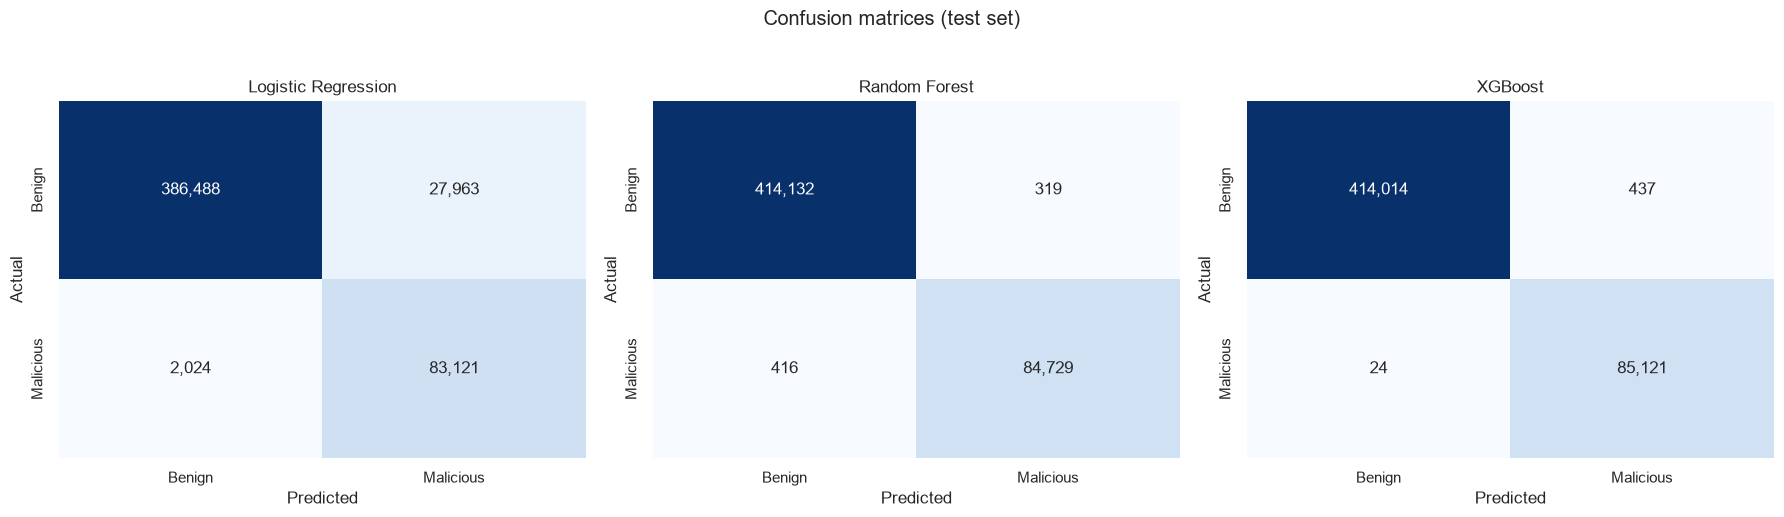

In [12]:
fig, axes = plt.subplots(1, len(trained), figsize=(6 * len(trained), 5))
if len(trained) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, trained.items()):
    cm = confusion_matrix(y_test, info["y_pred"])
    sns.heatmap(
        cm, annot=True, fmt=",d", cmap="Blues", cbar=False, ax=ax,
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.suptitle("Confusion matrices (test set)", y=1.03)
plt.tight_layout()
plt.show()

## 10. ROC and precision recall curves

These graphs give another way to compare the three models. The ROC curve shows how well each model separates the two classes, while the precision recall curve shows how well it finds attacks without creating too many false alarms.

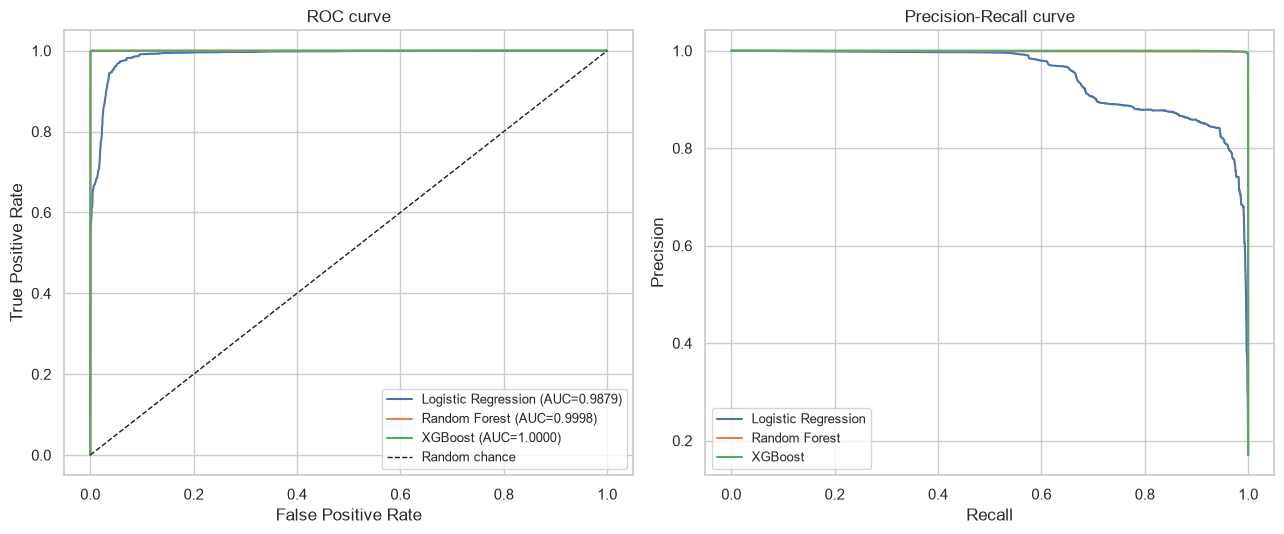

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5.5))

for name, info in trained.items():
    fpr, tpr, _ = roc_curve(y_test, info["y_proba"])
    ax1.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y_test, info['y_proba']):.4f})")

    prec, rec, _ = precision_recall_curve(y_test, info["y_proba"])
    ax2.plot(rec, prec, label=name)

ax1.plot([0, 1], [0, 1], "k--", linewidth=1, label="Random chance")
ax1.set_xlabel("False Positive Rate")
ax1.set_ylabel("True Positive Rate")
ax1.set_title("ROC curve")
ax1.legend(loc="lower right", fontsize=9)

ax2.set_xlabel("Recall")
ax2.set_ylabel("Precision")
ax2.set_title("Precision-Recall curve")
ax2.legend(loc="lower left", fontsize=9)

plt.tight_layout()
plt.show()

## 11. Model comparison table

A single table to compare all three models side by side and pick a winner.

In [14]:
comparison_df = pd.DataFrame(metrics_rows).set_index("Model").sort_values("F1", ascending=False)
display(comparison_df.style.format({
    "Accuracy": "{:.4%}", "Precision": "{:.4%}", "Recall": "{:.4%}",
    "F1": "{:.4%}", "ROC-AUC": "{:.4%}", "Train time (s)": "{:.1f}",
}).background_gradient(subset=["Accuracy", "Precision", "Recall", "F1", "ROC-AUC"], cmap="Greens"))

BEST_MODEL_NAME = comparison_df["F1"].idxmax()
print(f"\nBest model by F1 score: {BEST_MODEL_NAME}")

,Accuracy,Precision,Recall,F1,ROC-AUC,Train time (s)
Model,,,,,,
XGBoost,99.9077%,99.4892%,99.9718%,99.7299%,99.9981%,87.4
Random Forest,99.8529%,99.6249%,99.5114%,99.5681%,99.9802%,414.5
Logistic Regression,93.9978%,74.8272%,97.6229%,84.7184%,98.7904%,74.5



Best model by F1 score: XGBoost


## 12. Feature importance

Random forest and XGBoost can show which features they used the most when making predictions. I plotted the top 15 features for each model to see which parts of the network traffic had the biggest effect on their decisions.

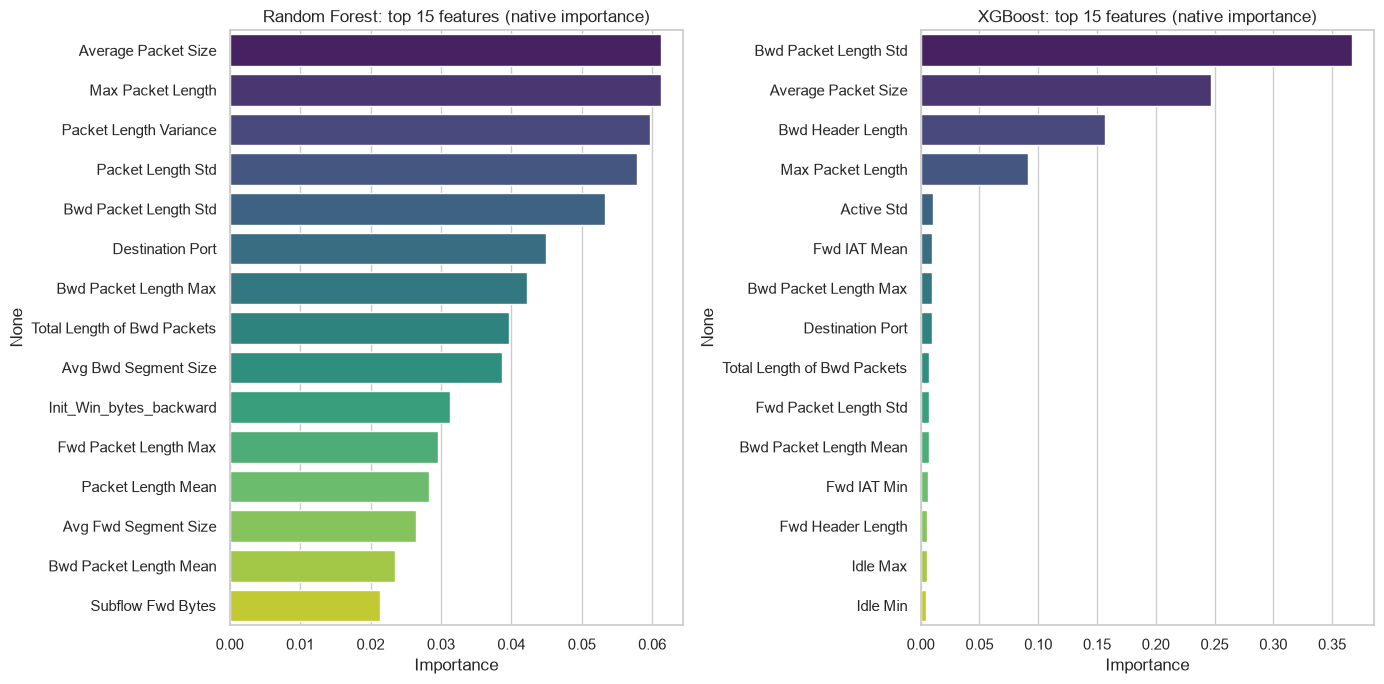

In [15]:
tree_models = {n: i for n, i in trained.items() if hasattr(i["model"], "feature_importances_")}

fig, axes = plt.subplots(1, len(tree_models), figsize=(7 * len(tree_models), 7))
if len(tree_models) == 1:
    axes = [axes]

for ax, (name, info) in zip(axes, tree_models.items()):
    importances = pd.Series(info["model"].feature_importances_, index=X.columns)
    top = importances.sort_values(ascending=False).head(15)
    sns.barplot(x=top.values, y=top.index, hue=top.index, palette="viridis", legend=False, ax=ax)
    ax.set_title(f"{name}: top 15 features (native importance)")
    ax.set_xlabel("Importance")

plt.tight_layout()
plt.show()

## 13. Permutation importance

I also used permutation importance to double check which features mattered most. It works by mixing up one feature at a time and checking how much the model’s F1 score decreases. If the score drops a lot, that feature was important to the model.

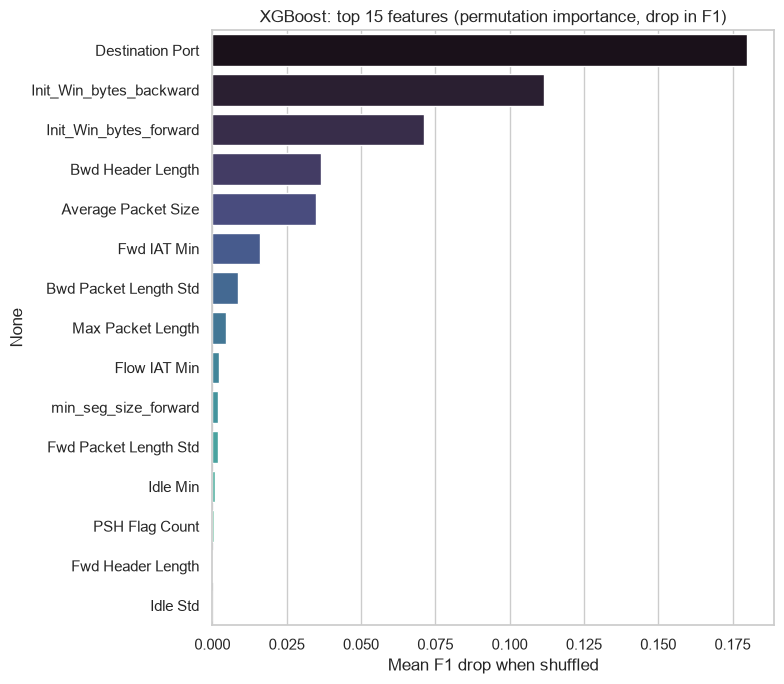

In [16]:
from sklearn.inspection import permutation_importance

best_info = trained[BEST_MODEL_NAME]
X_eval = pd.DataFrame(X_test_scaled, columns=X.columns) if best_info["uses_scaled"] else X_test
sample_idx = np.random.RandomState(RANDOM_STATE).choice(len(X_eval), size=5000, replace=False)

perm_result = permutation_importance(
    best_info["model"], X_eval.iloc[sample_idx], y_test.values[sample_idx],
    scoring="f1", n_repeats=5, random_state=RANDOM_STATE, n_jobs=-1,
)
perm_importances = pd.Series(perm_result.importances_mean, index=X.columns).sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(8, 7))
sns.barplot(x=perm_importances.values, y=perm_importances.index, hue=perm_importances.index,
            palette="mako", legend=False, ax=ax)
ax.set_title(f"{BEST_MODEL_NAME}: top 15 features (permutation importance, drop in F1)")
ax.set_xlabel("Mean F1 drop when shuffled")
plt.tight_layout()
plt.show()

## 14. SHAP explanation

I used SHAP to get a better idea of how each feature affected the model’s predictions. The graphs show which features pushed predictions more toward benign or malicious traffic.

Since SHAP can take a long time to run, I only used a random sample of the test data.

c:\Users\armen\Documents\Martin Personal\Martin Projects\Javascript Projects\Network Intrusion Detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


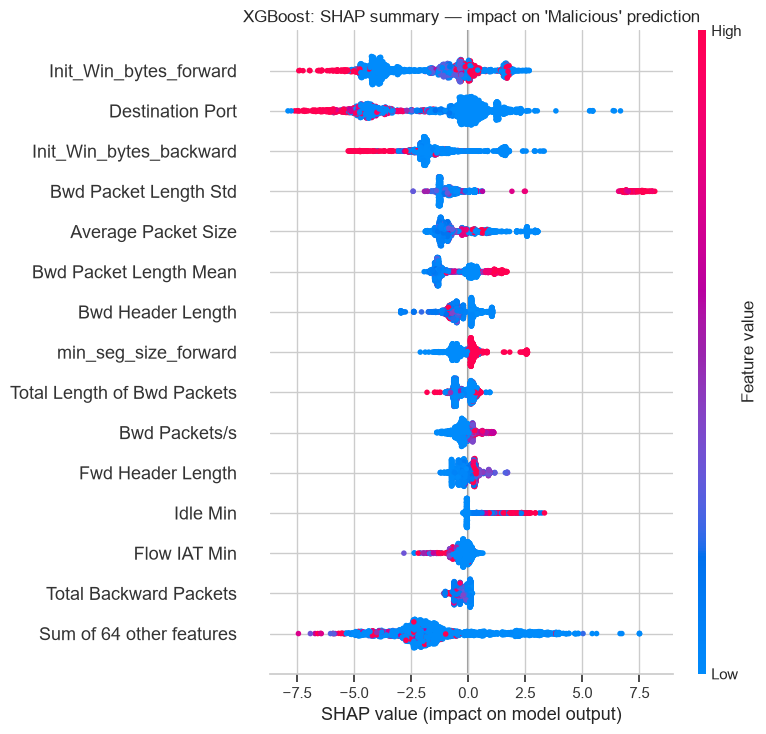

In [17]:
import shap

rng = np.random.RandomState(RANDOM_STATE)
sample_idx_shap = rng.choice(len(X_test), size=2000, replace=False)

if hasattr(best_info["model"], "feature_importances_"):
    X_shap_sample = X_test.iloc[sample_idx_shap]
    explainer = shap.TreeExplainer(best_info["model"])
else:
    background_idx = rng.choice(len(X_train_scaled), size=100, replace=False)
    X_background = pd.DataFrame(X_train_scaled[background_idx], columns=X.columns)
    X_shap_sample = pd.DataFrame(X_test_scaled[sample_idx_shap], columns=X.columns)
    explainer = shap.Explainer(best_info["model"], X_background)

shap_exp = explainer(X_shap_sample)

if shap_exp.values.ndim == 3:
    shap_exp = shap_exp[..., 1]

shap.plots.beeswarm(shap_exp, max_display=15, show=False)
plt.title(f"{BEST_MODEL_NAME}: SHAP summary — impact on 'Malicious' prediction")
plt.tight_layout()
plt.show()


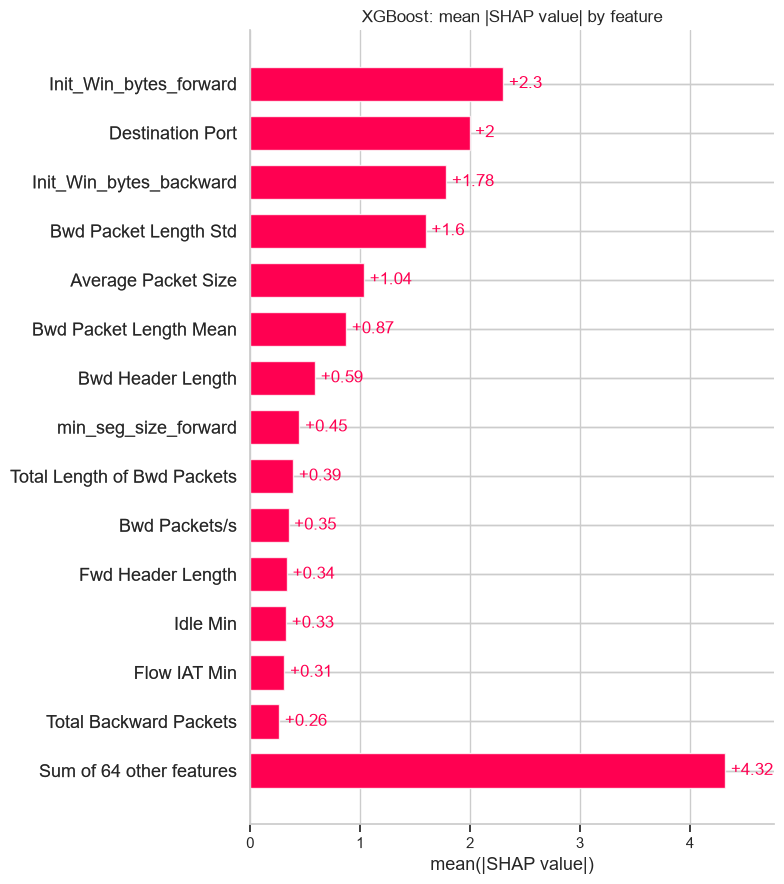

In [18]:
shap.plots.bar(shap_exp, max_display=15, show=False)
plt.title(f"{BEST_MODEL_NAME}: mean |SHAP value| by feature")
plt.tight_layout()
plt.show()

## 15. Prediction confidence and risk level

The model gives each network flow a probability of being an attack. I used this probability as the confidence score and separated the results into low, medium, and high risk groups. The risk levels are only simple examples and could be changed depending on how the model is used.

In [19]:
def risk_level(p):
    if p < 0.3:
        return "Low"
    elif p < 0.7:
        return "Medium"
    return "High"

y_proba_best = best_info["y_proba"]
y_pred_best = best_info["y_pred"]

sample_pos = np.random.RandomState(RANDOM_STATE).choice(len(X_test), size=15, replace=False)
sample_test_index = X_test.index[sample_pos]

predictions_df = pd.DataFrame({
    "Original label": df.loc[sample_test_index, "Label"].values,
    "Actual": [CLASS_NAMES[v] for v in y_test.values[sample_pos]],
    "Predicted": [CLASS_NAMES[v] for v in y_pred_best[sample_pos]],
    "Confidence (% Malicious)": (y_proba_best[sample_pos] * 100).round(2),
    "Risk level": [risk_level(p) for p in y_proba_best[sample_pos]],
})
display(predictions_df)

,Original label,Actual,Predicted,Confidence (% Malicious),Risk level
0,DDoS,Malicious,Malicious,100.0,High
1,BENIGN,Benign,Benign,0.0,Low
2,BENIGN,Benign,Benign,0.0,Low
3,BENIGN,Benign,Benign,0.0,Low
4,BENIGN,Benign,Benign,0.0,Low
5,BENIGN,Benign,Benign,0.0,Low
6,BENIGN,Benign,Benign,0.0,Low
7,DoS Hulk,Malicious,Malicious,100.0,High
8,BENIGN,Benign,Benign,0.0,Low
9,DoS Hulk,Malicious,Malicious,100.0,High


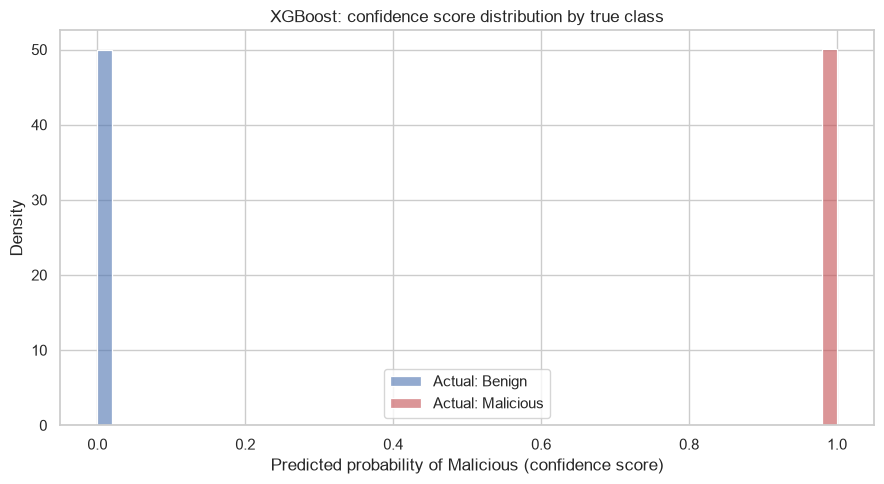

In [20]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(x=y_proba_best[y_test.values == 0], bins=50, color="#4C72B0",
             label="Actual: Benign", stat="density", alpha=0.6, ax=ax)
sns.histplot(x=y_proba_best[y_test.values == 1], bins=50, color="#C44E52",
             label="Actual: Malicious", stat="density", alpha=0.6, ax=ax)
ax.set_xlabel("Predicted probability of Malicious (confidence score)")
ax.set_title(f"{BEST_MODEL_NAME}: confidence score distribution by true class")
ax.legend()
plt.tight_layout()
plt.show()

## 16. Saving the model

I saved the best model in the models folder using joblib. I also saved the scaler and column names with it so the model can be loaded and used again without having to train it from the beginning.

In [21]:
import joblib

artifact = {
    "model": best_info["model"],
    "model_name": BEST_MODEL_NAME,
    "uses_scaled": best_info["uses_scaled"],
    "scaler": scaler,
    "feature_columns": list(X.columns),
    "class_names": CLASS_NAMES,
}

out_path = MODELS_DIR / "intrusion_detector.joblib"
joblib.dump(artifact, out_path)
print(f"Saved best model ({BEST_MODEL_NAME}) to {out_path}")
print(f"File size: {out_path.stat().st_size / 1e6:.1f} MB")

Saved best model (XGBoost) to c:\Users\armen\Documents\Martin Personal\Martin Projects\Javascript Projects\Network Intrusion Detection\models\intrusion_detector.joblib
File size: 0.9 MB


## Summary

In this project, I combined and cleaned about 2.8 million network flow records from the CIC-IDS2017 dataset. I changed the problem into two classes, benign and malicious, and trained logistic regression, random forest, and XGBoost models.

XGBoost had the best result with 99.91% accuracy and a 99.73% F1 score for attacks. Random forest was very close, while logistic regression gave more false alarms. I also compared the models with graphs and looked at their most important features before saving the best model.

The results were very high, but the dataset was collected in a controlled lab and I used a random train and test split. If I continued this project, I would test the model on a separate day of traffic and try predicting each attack type instead of putting all attacks into one group.